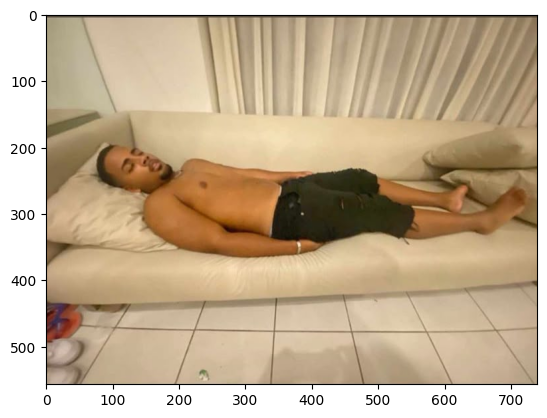

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_path = "/home/lucian/faculdade_6_semestre/engenharia-programas/programando_k-means_atividade_2/img/img.jpeg"

img  = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

plt.show()

Tamanho do c 3


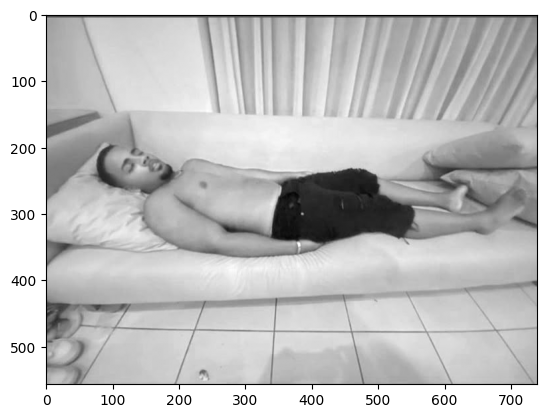

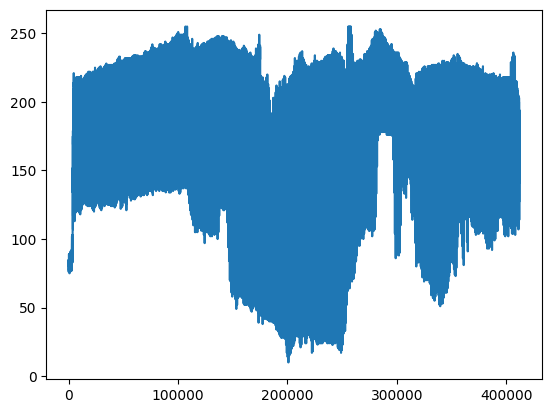

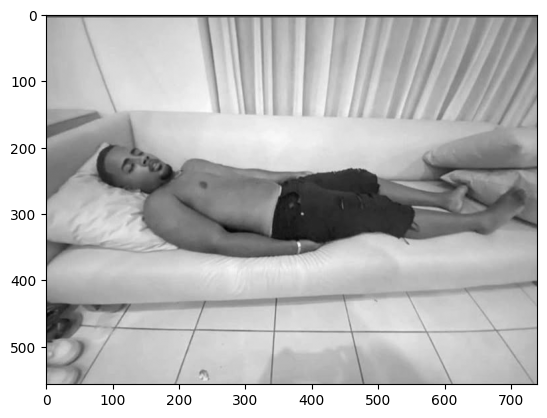

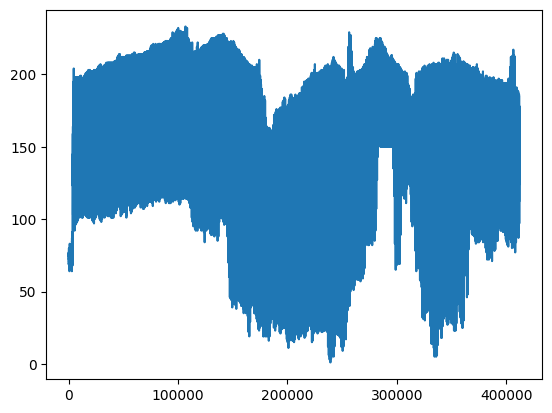

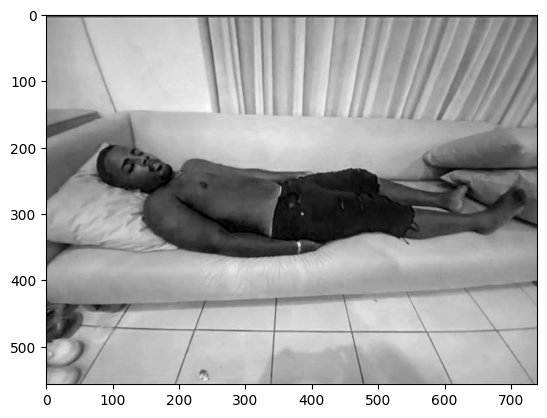

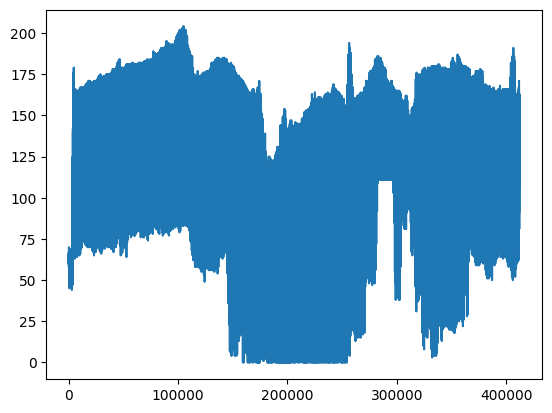

In [12]:
K = 10

n, m, c = img.shape

plano = []

faixa = []

print(f"Tamanho do c {c}")

for cor in range(c):
    plano.append(img[:,:,cor])
    plt.imshow(plano[-1], cmap='gray')
    plt.show()
    faixa.append(plano[-1].flatten())

    plt.plot(faixa[-1])
    plt.show()

In [13]:
centroid = []
v = []
n_pixels = len(faixa[0])

for k in range(K):
    px = np.random.randint(0, n_pixels)
    v0 = faixa[0][px]
    v1 = faixa[1][px]
    v2 = faixa[2][px]
    centroid.append([v0,v1,v2])
    print(f"centroid[{k}] = {centroid[k]}")


centroid[0] = [np.uint8(179), np.uint8(114), np.uint8(86)]
centroid[1] = [np.uint8(192), np.uint8(173), np.uint8(141)]
centroid[2] = [np.uint8(218), np.uint8(198), np.uint8(173)]
centroid[3] = [np.uint8(186), np.uint8(154), np.uint8(116)]
centroid[4] = [np.uint8(207), np.uint8(183), np.uint8(157)]
centroid[5] = [np.uint8(152), np.uint8(92), np.uint8(40)]
centroid[6] = [np.uint8(153), np.uint8(132), np.uint8(101)]
centroid[7] = [np.uint8(188), np.uint8(114), np.uint8(53)]
centroid[8] = [np.uint8(237), np.uint8(215), np.uint8(178)]
centroid[9] = [np.uint8(230), np.uint8(203), np.uint8(160)]


In [16]:

CLUSTER = [[] for _ in range(K)]
for px in range(n_pixels):
    v = [faixa[0][px],faixa[1][px],faixa[2][px]]
    d = []
    
    for k in range(K):
        d.append(np.linalg.norm(np.array(v) - np.array(centroid[k])))
    
    cluster = np.argmin(d)
    CLUSTER[cluster].append(px)

for k in range(K):
    print(f"Tamanho cluster {k+1}: {len(CLUSTER[k])}")


Tamanho cluster 1: 860
Tamanho cluster 2: 79621
Tamanho cluster 3: 13828
Tamanho cluster 4: 63388
Tamanho cluster 5: 59273
Tamanho cluster 6: 40598
Tamanho cluster 7: 71841
Tamanho cluster 8: 21501
Tamanho cluster 9: 43812
Tamanho cluster 10: 17458


In [21]:

new_centroid = []

for k in range(K):
    L = len(CLUSTER[k])
    s = np.zeros(3)
    for px in CLUSTER[k]:
        s += [faixa[0][px],faixa[1][px],faixa[2][px]]
    
    new_centroid.append([int(s[0]/L),int(s[1]/L),int(s[2]/L)])

print(f"Novos centroids {new_centroid}")

Novos centroids [[201, 141, 94], [207, 184, 150], [225, 206, 177], [195, 170, 133], [217, 195, 164], [156, 112, 66], [173, 152, 121], [162, 124, 82], [94, 70, 40], [234, 210, 168]]
